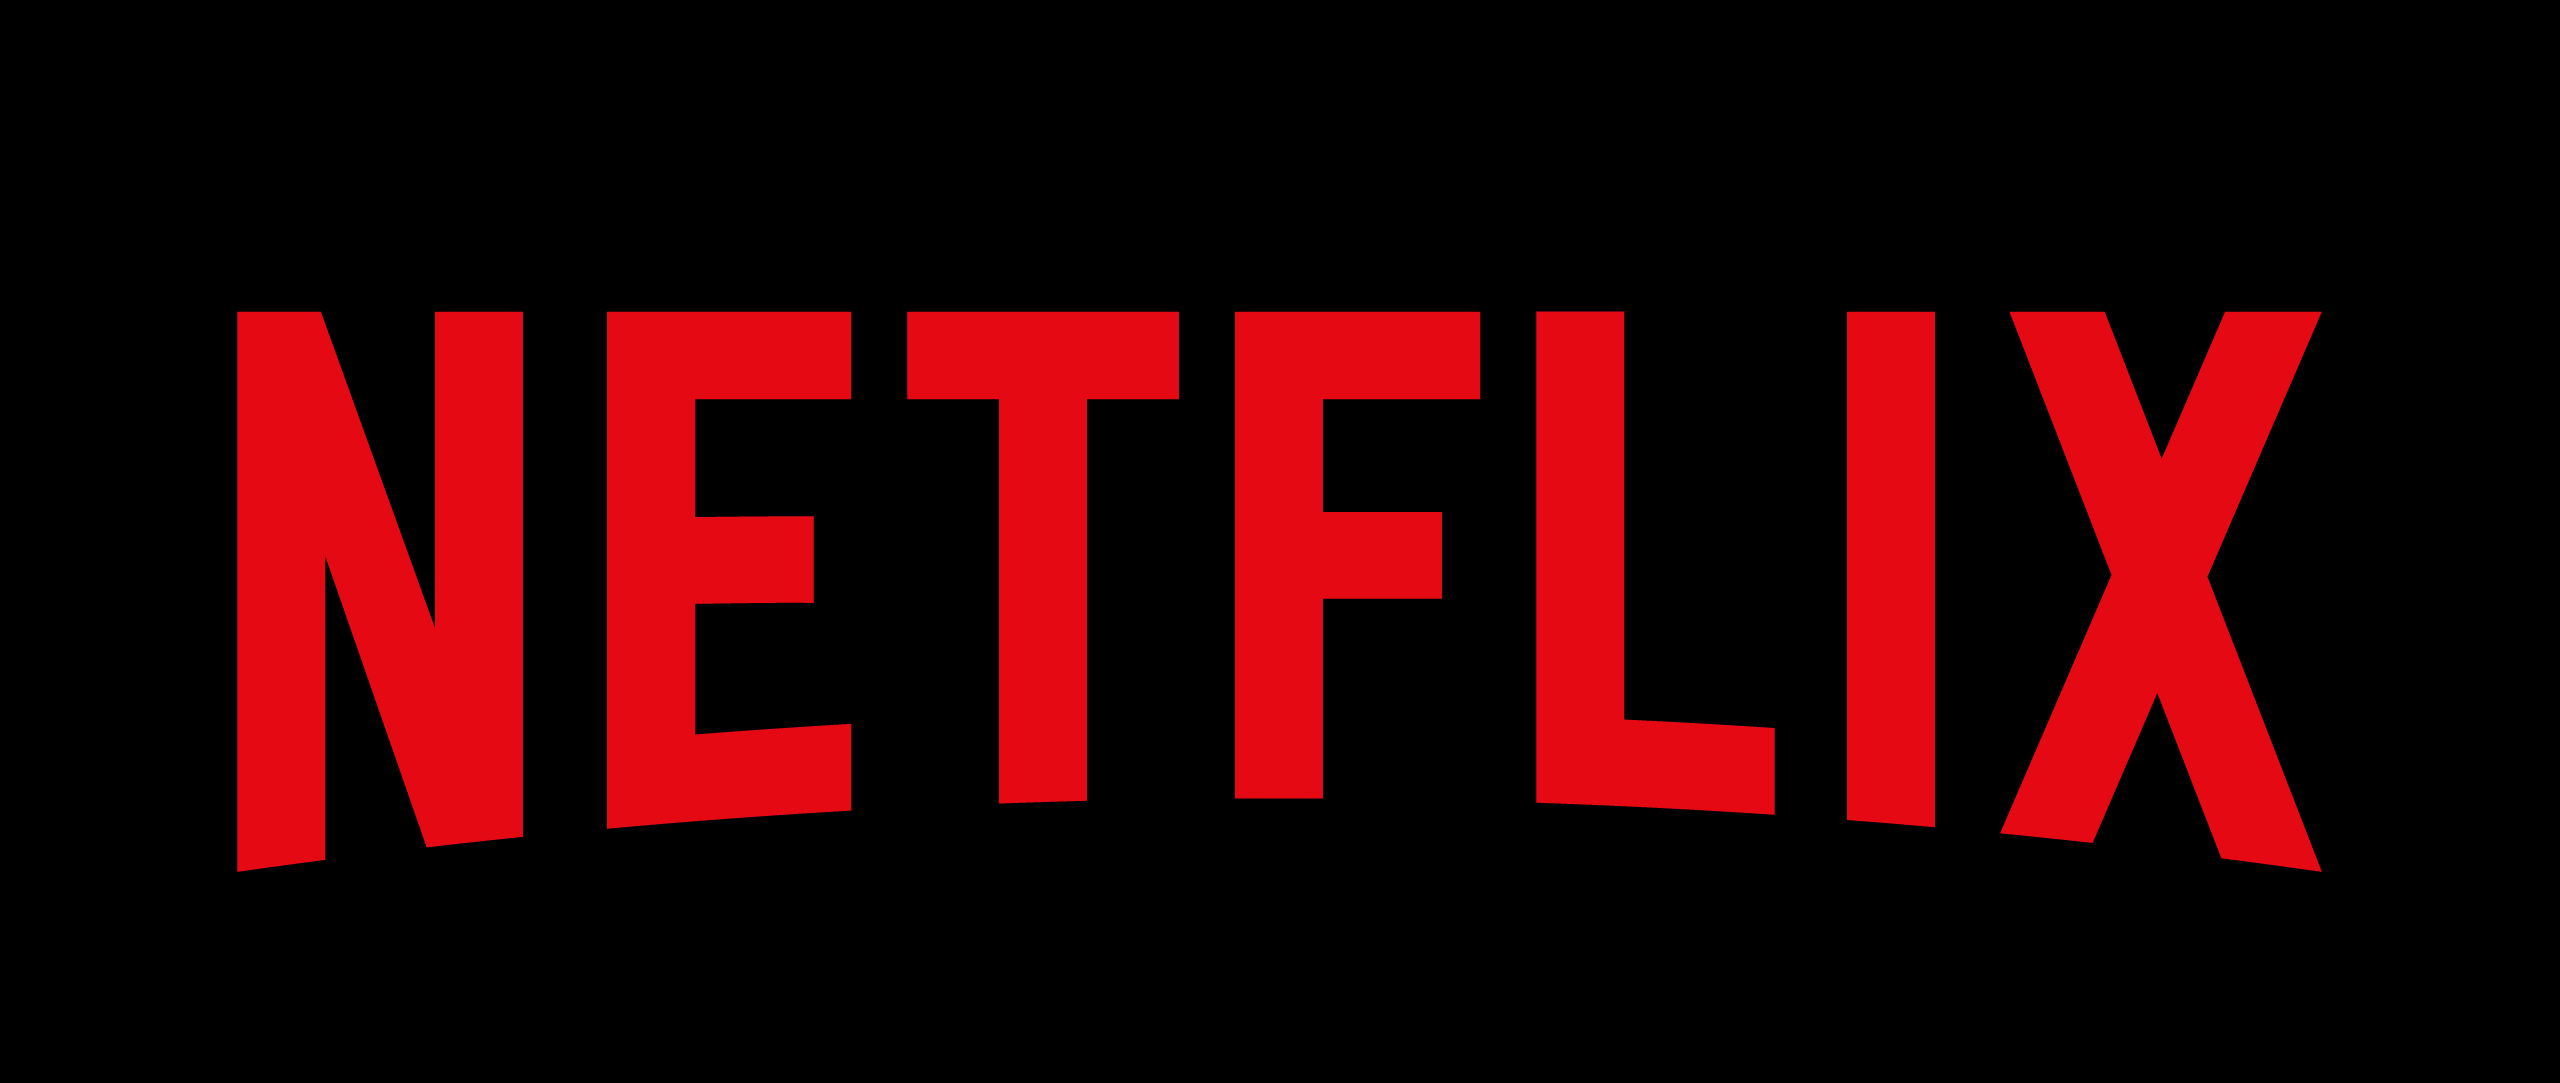

#Netflix Recommendation Engine

What are Recommender Systems?

Recommender systems are algorithms designed to suggest relevant items to users. These systems are used in various domains such as e-commerce, streaming services, and social media. They enhance user experience by filtering vast amounts of information to deliver personalized content

#Problem Statement

Customer Behaviour and it’s prediction lies
at the core of every Business Model. From
Stock Exchange, e-Commerce and
Automobile to even Presidential Elections,
predictions serve a great purpose. Most of
these predictions are based on the data
available about a person’s activity either
online or in-person.

Recommendation Engines are the much
needed manifestations of the desired
Predictability of User Activity.
Recommendation Engines move one step
further and not only give information but
put forth strategies to further increase users
interaction with the platform.

In today’s world OTT platform and Streaming
Services have taken up a big chunk in the
Retail and Entertainment industry.
Organizations like Netflix, Amazon etc.
analyse User Activity Pattern’s and suggest
products that better suit the user needs and
choices.

For the purpose of this Project we will be
creating one such Recommendation Engine
from the ground-up, where every single user,
based on there area of interest and ratings,
would be recommended a list of movies that
are best suited for them.

#Dataset Information

1. ID – Contains the separate keys for
customer and movies.
2. Rating – A section contains the user
ratings for all the movies.
3. Genre – Highlights the category of the
movie.
4. Movie Name – Name of the movie with
respect to the movie id.

#Objective

1. Find out the list of most popular and liked genre
2. Create Model that finds the best suited Movie for one
user in every genre.
3. Find what Genre Movies have received the best and
worst ratings based on User Rating.

#TASKS-

##Install and Import Libraries

##Load and Prepare the Dataset

##Train the Model

##Evaluate the Model

##Make Predictions

#_____________________________________________________________________________________________________________________

#Install and Import Libraries

In [1]:
#Install and Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load and Prepare the Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Reading the dataset

netflix_dataset= pd.read_csv('/content/drive/MyDrive/NETFLIX/combined_data_1.txt')
netflix_dataset

,,1:
1488844,3.0,2005-09-06
822109,5.0,2005-05-13
885013,4.0,2005-10-19
30878,4.0,2005-12-26
823519,3.0,2004-05-03
...,...,...
2591364,2.0,2005-02-16
1791000,2.0,2005-02-10
512536,5.0,2005-07-27
988963,3.0,2005-12-20


#Dataset Evaluation:

##-The data is not in the right format so we will first provide a Column name to the data along with the index number.

##-Since it is a simple prediction model so we will also remove the date column.

##-1: , 2: , 3: ,etc will have a NULL value and it means that it is a movie number and then a customer ID will be given a rating

##-i.e the customer ID is a set of customer which has given a rating to that movie.

In [4]:
netflix_dataset= pd.read_csv('/content/drive/MyDrive/NETFLIX/combined_data_1.txt',header = None, names = ['Cust_Id', 'Rating'], usecols = [0,1])
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [5]:
netflix_dataset.tail()

,Cust_Id,Rating
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0
24058262,1704416,3.0


In [6]:
netflix_dataset.dtypes

#customer ID is having object data type because of colon.
#Rating is having null value or numbers so it is Float type.

,0
Cust_Id,object
Rating,float64


In [7]:
netflix_dataset.isnull().sum()

,0
Cust_Id,0
Rating,4499


In [8]:
#get the movie count ( as the NaN values in Rating column will show how many movie are there )
movie_count=netflix_dataset.isnull().sum()
movie_count=movie_count["Rating"]
movie_count

4499

In [9]:
#to claculate how many customers we are having in the dataset
#We will take Total customer count's unique value but it will also have the Movie Id in it so we will remove it later

customer_count=netflix_dataset['Cust_Id'].nunique()

In [10]:
customer_count

475257

In [11]:
#Total number of customers that we have after removing movie id from the column

customer_count - movie_count

470758

In [12]:
#get the total number of ratings given by the customers

rating_count=netflix_dataset['Cust_Id'].count()-movie_count  # In Customer id column we will remove movie id to get how many total rating are there
rating_count

24053764

In [13]:
#To find out how many people have rated the movies as 1, 2, 3,4,5 stars ratings to the movies

stars=netflix_dataset.groupby('Rating')['Rating'].agg(['count'])  #with group by we are taking the unique Value of the rating on the left side,
                                                                  #And with aggrigate function we are taking how much times that value is present.

In [14]:
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


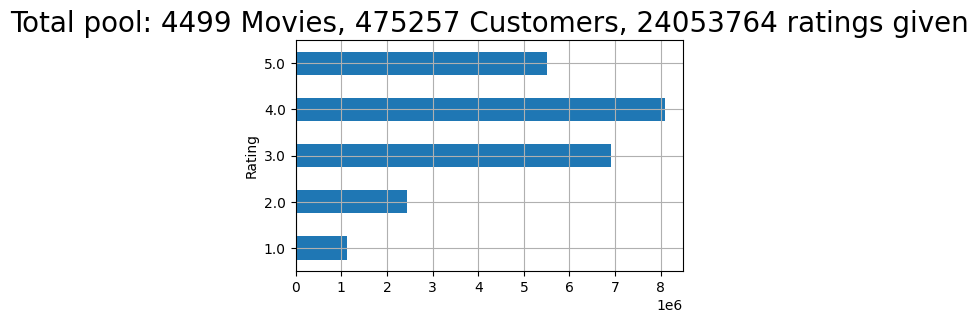

In [15]:
# We will visualise the same data with Total number of aggrigate rating on X Axis and Rating on the Y Axis.

ax=stars.plot(kind='barh', legend=False, figsize=(5,3))
plt.title(f'Total pool: {movie_count} Movies, {customer_count} Customers, {rating_count} ratings given', fontsize=20)
plt.grid(True)

In [16]:
# If we randomly select a data from our dataset, we will notice that we don't know which Movie number it is.

netflix_dataset.sample()

,Cust_Id,Rating
12758264,1819429,5.0


In [17]:
# We will add another column where we can can add the Movie number to understand which movie is being rated.

# Lets just make a clear dataframe to find how many MovieId are there

movie_id=None  # We will create a variable but we will not add any value to it

movie_np =[]  # Here we will add all the elements


# Iterate over the DataFrame rows


for cust_id in netflix_dataset['Cust_Id']:        # We will iterate through Customer Id Column

    if ':' in cust_id:                            # If we find any value with colon, we will replace it with '' (Blank), and make it an integer.

      # Update the current movie ID
      movie_id = int(cust_id.replace(':', ''))
    movie_np.append(movie_id)

In [18]:
def abc():
 None

In [19]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [20]:
# Now we will Add the new column to the DataFrame to showcase the Movie being rated

netflix_dataset['Movie_Id'] = movie_np

In [21]:
# Now it will show the movie number

netflix_dataset.sample()

,Cust_Id,Rating,Movie_Id
1271330,231001,3.0,283


In [22]:
# Now we will exclude rows where the 'Rating' is NaN to keep only the rows where the 'Rating' column is not null

netflix_dataset = netflix_dataset[netflix_dataset['Rating'].notna()]

In [23]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [24]:
netflix_dataset.info()  # Customer ID is object data type so we will convert it into Integer data type

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [25]:
netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)

/tmp/ipykernel_3603/358752458.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)


In [26]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


#pre-filtering -

##now we will remove all the users that have rated less to the movies and also all those movies that has been rated less in numbers because it is a recommendation engine and the movies suggested must be with good rating.

In [27]:
dataset_movie_summary=netflix_dataset.groupby('Movie_Id')['Rating'].agg(["count"])  # We will take the movie on the left and the aggrigate of the total
                                                                                    #ratings that movie has got.

In [28]:
dataset_movie_summary

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [29]:
# Now we will create a benchmark

movie_benchmark=round(dataset_movie_summary['count'].quantile(0.6)) # Here we will take the 60% (Randomly) Quanile of the entire column as a benchmark.
movie_benchmark

908

In [30]:
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index   # Now we will select all the movies having rating below the benchmark
drop_movie_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [31]:
len(drop_movie_list)

2699

In [32]:
# Now we will check all the users that are in-active

dataset_cust_summary=netflix_dataset.groupby('Cust_Id')['Rating'].agg(["count"])  # We will put customer Id on the left and their aggrigate review count on the right
dataset_cust_summary

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [33]:
# Now we will create a benchmark for the customer's review count

cust_benchmark=round(dataset_cust_summary['count'].quantile(0.6))  # Here we will take the 60% (Randomly) Quanile of the entire column as a benchmark.
cust_benchmark

36

In [34]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index  # Now we will select all the inactive customers below the benchmark.
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=282042)

In [35]:
len(drop_cust_list)

282042

In [36]:
netflix_dataset=netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]  # We will remove all the elements present in drop_movie_list
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_list)]    # We will remove all the elements present in drop_cust_list
print(netflix_dataset.shape)

(19695836, 3)


In [37]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


Singular Value Decomposition, or SVD for short, is a powerful mathematical tool used in data analysis and machine learning. At its core, SVD is a method for decomposing a matrix into its constituent parts, which can be thought of as a way to extract meaningful information from complex data. This makes it an incredibly useful tool for a wide range of applications, from image compression to natural language processing.



##So why is this useful?

• SVD can be used for a variety of tasks, such as data compression, noise reduction, and feature extraction. It is particularly useful in machine learning and data analysis, where it can be used to identify patterns and relationships in large datasets. By breaking down a matrix into its constituent parts, we can gain a deeper understanding of the data and make more informed decisions based on our findings.



##Applications of SVD in Python

• SVD has proven to be a powerful tool in various applications, including image compression, recommendation systems, and natural language processing. In image compression, SVD is used to reduce the size of an image without losing significant amounts of information. This is achieved by decomposing the image into its singular values and retaining only the most important ones. The result is a compressed image that takes up less space while still maintaining its quality.

• In recommendation systems, SVD is used to analyze user behavior and predict their preferences. By decomposing the user-item matrix, SVD can identify hidden patterns and relationships between users and items, allowing for more accurate recommendations. Similarly, in natural language processing, SVD can be used to analyze large datasets of text and identify semantic relationships between words and phrases. This allows for more accurate language modeling and text prediction.

#______________________________________________________________________________________________________________

#Model Building

In [38]:
df_title= pd.read_csv('/content/drive/MyDrive/NETFLIX/movie_titles.csv', encoding='ISO-8859-1', header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name' ])

# WE can't load this data directly because it uses ISO-8859-1 encoding (not standard UTF-8) to handle special characters and lacks a header row.
# Initial dataset is not having any column name so we are providing the column name by using index value.

In [39]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [40]:
!pip install scikit-surprise

# Surprise library package is used for building and analysing recommendation systems.
# It provides tools to work with algorithms.

In [41]:
!pip install numpy==1.26.4  # We will install the compatible version of Numpy

In [42]:
from surprise import Reader, Dataset, SVD  # We need this to build a SVD model.
from surprise.model_selection import cross_validate # We will use it to build multiple models with multiple validation set.

In [43]:
reader=Reader()

# We will create reader as an object so that we can pass any Data Frame to a SVD model so that it can consider data in a table form.

In [44]:
# We only work with top 100K rows for quick runtime as the dataset is very large.

data=Dataset.load_from_df(netflix_dataset[['Cust_Id','Movie_Id','Rating']][:100000], reader)

In [45]:
model=SVD() # LinearRegression()  # Creating a SVD model

# Model Training & Testing

In [46]:
cross_validate(model, data, measures=['RMSE'], cv=3) # We will fit the data via cross validation

# We will pass the model along with the data.
# Since it is a Regression model, for the measures we will pass the Root Mean Square Error (RMSE).
# With cross validation= 3, It will build the model three times.

{'test_rmse': array([1.01667383, 1.01749781, 1.02492198]),
 'fit_time': (2.1085352897644043, 4.582499980926514, 3.019292116165161),
 'test_time': (0.41489720344543457, 3.1479451656341553, 0.4137120246887207)}

#Recommendation

In [47]:
netflix_dataset  # Filtered data set with movies having reviews more than 908 and customers who have seen more than 36 movies.

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [48]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


##We will take one random customer and We will give him the movies which he can see based on his watch history.

In [49]:
# Filter the dataset for the specific user

user_ratings = netflix_dataset[netflix_dataset['Cust_Id'] == 1055714 ]
user_ratings

,Cust_Id,Rating,Movie_Id
42163,1055714,5.0,18
92227,1055714,4.0,28
210936,1055714,2.0,30
262254,1055714,5.0,57
279656,1055714,5.0,58
...,...,...,...
23805263,1055714,5.0,4432
23945242,1055714,4.0,4472
23977663,1055714,5.0,4479
24018719,1055714,5.0,4488


In [50]:
# Find the number of unique movies rated by the user

movies_rated_by_user = user_ratings['Movie_Id'].nunique()

movies_rated_by_user

340

In [51]:
user_1055714	=df_title.copy()   # Making a copy for each individual customer for the recomendation as we don't want to change anything in Df_Title
user_1055714

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [52]:
user_1055714=user_1055714[~user_1055714['Movie_Id'].isin(drop_movie_list)]
user_1055714

# We will drop all the movies which are not worth suggesting.

,Movie_Id,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [53]:
user_1055714['Estimate_Score']=user_1055714['Movie_Id'].apply(lambda x: model.predict(1055714, x).est)

# Now we will go with a Function called Estimation Score.
# For the random user from the Movie ID column, we will asl SVD model to predict by passing the customer ID and Value X
# X here is every single Movie ID with respect to the customer ID based on the model.

# predict the score (rating) that a user (with user ID 1055714) might give to a list of movies.

# Estimate_Score - the prediction of SVD, which will tell the importance of each movie for individual customer (Range 0-5)
# HIGHER THE ESTIMATION SCORE, BETTER THE RELATION BETWEEN CUST_ID AND MOVIE

/tmp/ipykernel_3603/3987574914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1055714['Estimate_Score']=user_1055714['Movie_Id'].apply(lambda x: model.predict(1055714, x).est)


In [54]:
user_1055714

,Movie_Id,Year,Name,Estimate_Score
2,3,1997.0,Character,3.684507
4,5,2004.0,The Rise and Fall of ECW,3.220621
5,6,1997.0,Sick,3.049124
7,8,2004.0,What the #$*! Do We Know!?,3.710973
15,16,1996.0,Screamers,3.310170
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.697591
17766,17767,2004.0,Fidel Castro: American Experience,3.697591
17767,17768,2000.0,Epoch,3.697591
17768,17769,2003.0,The Company,3.697591


In [55]:
user_1055714.sort_values('Estimate_Score', ascending=False)  # We will sort the data in the ascending order

,Movie_Id,Year,Name,Estimate_Score
17,18,1994.0,Immortal Beloved,4.261042
27,28,2002.0,Lilo and Stitch,4.096625
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,3.835926
7,8,2004.0,What the #$*! Do We Know!?,3.710973
10234,10235,2000.0,Teen Spirit: A Tribute to Kurt Cobain,3.697591
...,...,...,...,...
4,5,2004.0,The Rise and Fall of ECW,3.220621
23,24,1981.0,My Bloody Valentine,3.203775
16,17,2005.0,7 Seconds,3.095851
5,6,1997.0,Sick,3.049124


In [56]:
Final_recomnadation_1055714=user_1055714.sort_values('Estimate_Score', ascending=False)
Final_recomnadation_1055714.head(5)

,Movie_Id,Year,Name,Estimate_Score
17,18,1994.0,Immortal Beloved,4.261042
27,28,2002.0,Lilo and Stitch,4.096625
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,3.835926
7,8,2004.0,What the #$*! Do We Know!?,3.710973
10234,10235,2000.0,Teen Spirit: A Tribute to Kurt Cobain,3.697591


In [57]:
top5_movies=user_1055714.sort_values('Estimate_Score', ascending=False).head(5)
top5_movies

,Movie_Id,Year,Name,Estimate_Score
17,18,1994.0,Immortal Beloved,4.261042
27,28,2002.0,Lilo and Stitch,4.096625
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,3.835926
7,8,2004.0,What the #$*! Do We Know!?,3.710973
10234,10235,2000.0,Teen Spirit: A Tribute to Kurt Cobain,3.697591


#Our Recommendation Engine is ready.
##To find the movie prediction for a new customer, We will first create a new DataFrame with a Customer ID of a random customer and for that customer we will again follow the same steps as done before.

#___________________________________________________________________________________________________________________